# Does a whole V block invert together?

*Setup cells below are carried from the shared analysis so this notebook runs on its own.*


In [1]:
from pathlib import Path

import polars as pl

from fraud_detection.evaluation.time_consistency import scan, time_windows

C = [f"C{i}" for i in range(1, 15)]
D = [f"D{i}" for i in range(1, 16)]
M = [f"M{i}" for i in range(1, 10)]
V = [f"V{i}" for i in range(1, 340)]
FEATURES = C + D + M + V

# ../input on a Kaggle kernel, kaggle/raw locally (see kaggle/download.py)
CANDIDATES = [
    Path("../input/ieee-fraud-detection/train_transaction.csv"),
    Path("../../kaggle/raw/train_transaction.csv"),
    Path("../kaggle/raw/train_transaction.csv"),
    Path("kaggle/raw/train_transaction.csv"),
]
csv = next((p for p in CANDIDATES if p.exists()), None)
if csv is None:
    raise FileNotFoundError(
        "train_transaction.csv not found. On Kaggle, add the ieee-fraud-detection "
        "competition data to this notebook; locally, run `uv run python kaggle/download.py`."
    )

df = pl.read_csv(
    csv,
    columns=["TransactionDT", "isFraud"] + FEATURES,
    schema_overrides={c: pl.Float32 for c in V},
)
print(f"{len(df):,} rows, {len(FEATURES)} features")

590,540 rows, 377 features


In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

DAY = 86400

# Categorical slots, checked for colour-vision deficiency across every pair.
PASS, INVERTED, WEAK = "#2a78d6", "#eb6834", "#1baf7a"
VERDICT_COLOR = {"pass": PASS, "inverted": INVERTED, "weak": WEAK}
BLUE_LIGHT = "#9ec5f4"
INK, MUTED, GRID, SURFACE = "#0b0b0b", "#898781", "#e1e0d9", "#fcfcfb"

# Signed magnitude gets a diverging ramp: degradation red, improvement blue, gray at 0.
DELTA_CMAP = LinearSegmentedColormap.from_list("delta", ["#e34948", "#f0efec", PASS])

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 130, "font.size": 9, "text.color": INK,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "legend.frameon": False,
})

In [3]:
train, holdout = time_windows(df, "TransactionDT", train=(0.0, 0.17), holdout=(0.83, 1.0))
print(f"train {len(train):,}   skipped {len(df) - len(train) - len(holdout):,}   holdout {len(holdout):,}")

train 100,392   skipped 389,755   holdout 100,393


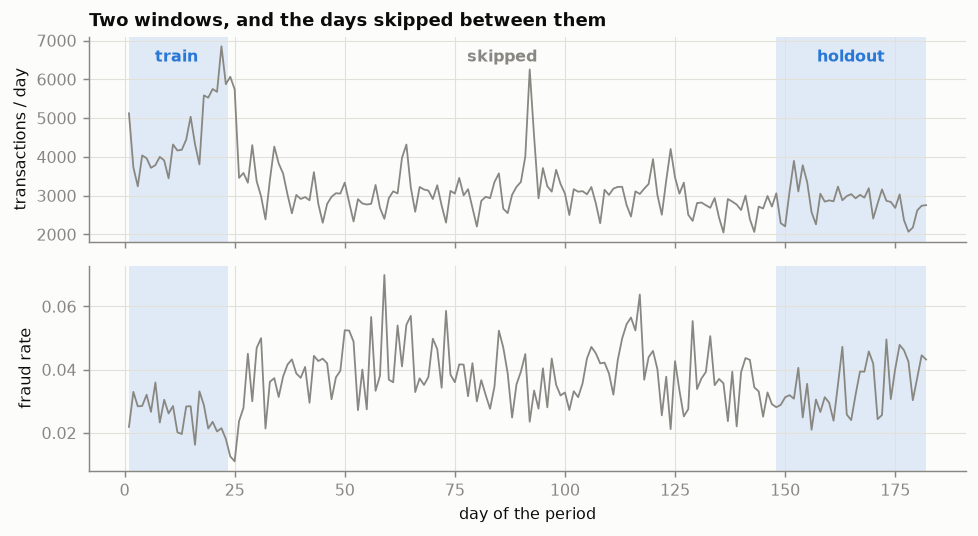

In [4]:
fig, (ax_v, ax_f) = plt.subplots(2, 1, figsize=(7.6, 4.2), sharex=True)

by_day = (
    df.with_columns((pl.col("TransactionDT") // DAY).cast(pl.Int64).alias("day"))
    .group_by("day")
    .agg(pl.len().alias("volume"), pl.col("isFraud").mean().alias("rate"))
    .sort("day")
)
day, volume, rate = (by_day[c].to_numpy() for c in ("day", "volume", "rate"))
t_hi = train["TransactionDT"].max() / DAY
h_lo = holdout["TransactionDT"].min() / DAY

for ax in (ax_v, ax_f):
    ax.axvspan(day.min(), t_hi, color=PASS, alpha=0.13, lw=0)
    ax.axvspan(h_lo, day.max(), color=PASS, alpha=0.13, lw=0)

ax_v.plot(day, volume, color=MUTED, lw=1)
ax_v.set_ylabel("transactions / day")
ax_v.set_title("Two windows, and the days skipped between them")
for x, text, color in [
    (t_hi / 2, "train", PASS),
    ((t_hi + h_lo) / 2, "skipped", MUTED),
    ((h_lo + day.max()) / 2, "holdout", PASS),
]:
    ax_v.text(x, 0.88, text, ha="center", color=color, fontweight="bold",
              transform=ax_v.get_xaxis_transform())

ax_f.plot(day, rate, color=MUTED, lw=1)
ax_f.set_ylabel("fraud rate")
ax_f.set_xlabel("day of the period")
fig.tight_layout()

In [5]:
scan(train, holdout, ["C3", "C7"], "isFraud").select(
    ["feature", "verdict", "auc_train", "auc_holdout", "delta"]
)

feature,verdict,auc_train,auc_holdout,delta
str,str,f64,f64,f64
"""C3""","""weak""",0.5055,0.502,-0.0035
"""C7""","""pass""",0.6508,0.6637,0.0129


## 2. Block Result: V322-V339

Result: `V322–V339` (18 columns) block degrades over time.

In [8]:
block = scan(train, holdout, [f"V{i}" for i in range(322, 340)], "isFraud")
print(block["verdict"].value_counts().sort("count", descending=True), "\n")
block.select(["feature", "verdict", "auc_train", "auc_holdout", "delta"])

shape: (2, 2)
┌──────────┬───────┐
│ verdict  ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ inverted ┆ 12    │
│ pass     ┆ 6     │
└──────────┴───────┘ 



feature,verdict,auc_train,auc_holdout,delta
str,str,f64,f64,f64
"""V335""","""inverted""",0.5722,0.4681,-0.104
"""V334""","""inverted""",0.5676,0.4649,-0.1026
"""V336""","""inverted""",0.5708,0.4715,-0.0993
"""V325""","""inverted""",0.5613,0.464,-0.0972
"""V338""","""inverted""",0.5698,0.4755,-0.0943
…,…,…,…,…
"""V331""","""pass""",0.5799,0.4859,-0.0941
"""V333""","""pass""",0.5843,0.4934,-0.0909
"""V322""","""pass""",0.5669,0.49,-0.0769


In [6]:
b = block.sort("auc_holdout")
y = range(len(b))

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.axvline(0.5, color=MUTED, lw=1)
ax.hlines(y, b["auc_train"], b["auc_holdout"], color=GRID, lw=1.6, zorder=1)
ax.scatter(b["auc_train"], y, s=36, color=BLUE_LIGHT, zorder=2,
           edgecolor=SURFACE, linewidth=1.4, label="train window")
ax.scatter(b["auc_holdout"], y, s=36, color=PASS, zorder=3,
           edgecolor=SURFACE, linewidth=1.4, label="holdout window")

ax.set_yticks(list(y), b["feature"].to_list())
ax.set_xlabel("single-feature AUC")
ax.set_title("V322-V339: all eighteen move the same way, across the 0.5 line")
ax.text(0.5, len(b) - 0.4, " no signal", color=MUTED, va="center", fontsize=8)
ax.grid(axis="y", visible=False)
ax.legend(loc="center")  # the band between the two clusters is the only empty space
fig.tight_layout()

NameError: name 'block' is not defined

Every column in the V322-V339 block degrades (delta roughly -0.09). It is better to remove the entire block rather than filtering per-column, as they share the same missingness structure.